# Quarterly forecasting on a CPU: from public data to a shared residual network

Train one small numerical model across GDP, unemployment, industrial production and labour
costs. Compare it with **seasonal naive** and **additive damped Holt-Winters exponential smoothing**
on the same series, forecast origins and observed targets. You will see the data, gaps, split,
learning curves, scores and forecasts, then save an auditable experiment record.

By default, this reads the existing **`data/snapshot/starter/`** snapshot. It does not fetch,
re-export or modify it. Set `SNAPSHOT` to another existing name/path, or explicitly choose
`INPUT_MODE="sources"` for the original source-file acquisition route.

This is a miniature *foundation-style training pattern*: shared weights learn across many series.
It is a supervised global forecasting model, not a pretrained foundation model or a zero-shot study.
Series seen in training are forecast at later dates. Inputs contain numbers and observation masks;
metadata is used for sampling, provenance and labels only.

**Setup, from the repository root:**
```powershell
uv venv --python 3.12
uv pip install -e ".[notebook,forecast]"
.venv\Scripts\jupyter lab notebooks/quarterly_forecasting.ipynb
```
On macOS/Linux use `.venv/bin/jupyter`. Select this environment's Python kernel. PyTorch runs
explicitly on CPU (two threads); no GPU or API key is needed. The default uses at most 256 series
and 25 epochs. Source mode download time is separate and depends on Eurostat.

The existing [ingestion tour](getting_started.ipynb) explains the storage layers in more detail.

In [1]:
import copy, hashlib, importlib.metadata, json, os, platform, subprocess, sys, textwrap, time, warnings
from pathlib import Path
import datetime as dt
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
from torch import nn
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from terrastat.config import data_dir
from terrastat import pipeline
from terrastat.series import build_series
from terrastat.forecasting import (
    quarter_dates, quarterly_panel, make_windows, normalize_context, score_forecasts, snapshot_candidates,
)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())

def display_path(path):
    """Keep machine-specific parent folders out of saved notebook outputs."""
    path = Path(path).resolve()
    try:
        return path.relative_to(ROOT.resolve()).as_posix()
    except ValueError:
        return f"<external>/{path.name}"

SEED, CONTEXT, HORIZON, EPOCHS = 7, 24, 4, 25
PER_DATASET, CANDIDATES_PER_DATASET = 64, 512
DATASETS = ["namq_10_gdp", "une_rt_q", "sts_inpr_q", "lc_lci_r2_q"]
INPUT_MODE = os.getenv("TERRASTAT_TUTORIAL_INPUT", "snapshot")
SNAPSHOT = os.getenv("TERRASTAT_TUTORIAL_SNAPSHOT", "starter")  # existing name or directory
GEOS = None  # retain the snapshot's geographic selection; optionally supply a list of codes
DATES = quarter_dates(2000, 2025)
TRAIN_END = dt.date(2022, 10, 1)
TRAIN_STOP = DATES.index(TRAIN_END) + 1
VALID_ORIGIN = DATES.index(dt.date(2023, 1, 1))
TEST_ORIGINS = [DATES.index(dt.date(y, 1, 1)) for y in (2024, 2025)]
SMOKE = os.getenv("TERRASTAT_TUTORIAL_SMOKE") == "1"  # CI: synthetic plumbing only
if SMOKE:
    EPOCHS, PER_DATASET = 2, 8
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.figsize": (11, 3.5), "axes.spines.top": False, "axes.spines.right": False})
print("CPU:", platform.processor() or platform.machine(), "| Python:", platform.python_version())
print("Data root:", display_path(data_dir()), "| Synthetic CI smoke:", SMOKE)

CPU: Intel64 Family 6 Model 165 Stepping 2, GenuineIntel | Python: 3.12.7
Data root: .\data | Synthetic CI smoke: False


## 1. Read the current snapshot, or explicitly acquire source data

The default reads `starter` through `dataset.load`: **only `shard-*.parquet` contains series**;
`index.parquet` is a lookup table and is excluded. The existing float32 value lists, sparse dates,
flags and provenance need no migration. Snapshot mode never falls back to fetching if a file or
quarterly subset is missing. Checksums are verified when present in the existing manifest.

Optional `INPUT_MODE="sources"` reuses quarterly source files or fetches missing datasets through
terrastat's paced Eurostat adapter, then builds the series view. This does not crawl the full corpus.
Eurostat needs no key. Keep source metadata and attribution alongside the data.

The source files are sparse: an absent quarter is reconstructed as missing before modeling.
Read a bounded candidate sample from each file, then determine eligibility from **training dates only**.
Dataset caps make this a teaching subset, not a representative economic panel. Snapshot mode
retains the snapshot's geographic selection unless `GEOS` is explicitly set.

In [2]:
files, snapshot_root = [], None
if not SMOKE and INPUT_MODE == "snapshot":
    from terrastat.datasets import verify
    snapshot_root = Path(SNAPSHOT).expanduser()
    if not snapshot_root.is_absolute() and (ROOT / snapshot_root).is_dir():
        snapshot_root = ROOT / snapshot_root
    if not snapshot_root.is_dir():
        snapshot_root = data_dir() / "snapshot" / SNAPSHOT
    snapshot_root = snapshot_root.resolve()
    if not snapshot_root.is_dir():
        raise FileNotFoundError(f"Existing snapshot not found: {snapshot_root}. Set SNAPSHOT to its name/path.")
    manifest_file = snapshot_root / "manifest.json"
    if manifest_file.exists():
        verification = verify(snapshot_root)
        print("Snapshot verification:", verification)
        if not verification["complete"]:
            raise RuntimeError("Snapshot verification failed; inspect the files before training.")
    files = sorted(snapshot_root.glob("shard-*.parquet"))
    files += [p for p in [manifest_file, snapshot_root / "index.parquet"] if p.exists()]
    candidates = snapshot_candidates(snapshot_root, DATASETS, CANDIDATES_PER_DATASET, SEED, GEOS)
    print("Reading existing snapshot:", display_path(snapshot_root))
elif not SMOKE and INPUT_MODE == "sources":
    files = [data_dir() / "series" / "eurostat" / "freq=Q" / f"{name}.parquet" for name in DATASETS]
    missing = [name for name, path in zip(DATASETS, files) if not path.exists()]
    if missing:
        catalog = pipeline.load_catalog("eurostat")
        refs = pipeline.select_refs("eurostat", catalog, ids=missing)
        if {r.dataset_id for r in refs} != set(missing):
            raise RuntimeError("Some requested dataset IDs are absent from the Eurostat catalogue.")
        print(pipeline.run_fetch("eurostat", refs, retry_failed=True, max_hours=.25))
        print(build_series("eurostat", dataset_ids=missing))
    absent = [str(path) for path in files if not path.exists()]
    if absent:
        raise RuntimeError(f"Quarterly files are still absent. Inspect fetch status and rerun: {absent}")

    columns = ["series_uid", "source", "dataset_id", "title", "units", "geo", "frequency",
               "dates", "values", "license_id", "attribution", "retrieved_at"]
    candidates = pl.concat([
        pl.scan_parquet(path).filter((pl.col("geo").is_in(GEOS) if GEOS is not None else pl.lit(True))
                                    & (pl.col("frequency") == "Q"))
        .with_columns(pl.col("series_uid").hash(seed=SEED).alias("_rank"))
        .sort("_rank").head(CANDIDATES_PER_DATASET).select(columns).collect()
        for path in files
    ])
elif SMOKE:
    # Never used as a silent fallback for failed downloads or missing real data.
    rng = np.random.default_rng(SEED)
    rows = []
    t = np.arange(len(DATES))
    for dataset in DATASETS:
        for i in range(12):
            values = (50 + .2*t + 3*np.sin(2*np.pi*t/4) + rng.normal(0, .5, len(t))) * (i+1)
            values[30] = np.nan
            rows.append(dict(series_uid=f"synthetic:{dataset}:{i}", source="synthetic", dataset_id=dataset,
                title=f"Synthetic {dataset} {i}", units="arbitrary", geo="AT", frequency="Q", dates=DATES,
                values=values.tolist(), license_id="synthetic", attribution="Generated for CI only", retrieved_at=None))
    # Exercise the same snapshot reader with the existing float32/list schema and lookup index.
    import tempfile
    with tempfile.TemporaryDirectory() as smoke_dir:
        smoke_root = Path(smoke_dir)
        fixture = pl.DataFrame(rows).with_columns(pl.lit("eurostat").alias("source"),
                                                pl.col("values").cast(pl.List(pl.Float32)))
        fixture.write_parquet(smoke_root / "shard-00000.parquet")
        fixture.select("series_uid", "frequency").write_parquet(smoke_root / "index.parquet")
        candidates = snapshot_candidates(smoke_root, DATASETS, CANDIDATES_PER_DATASET, SEED, GEOS)
else:
    raise ValueError("INPUT_MODE must be 'snapshot' or 'sources'")

metadata, panel, audit = quarterly_panel(candidates, DATES, TRAIN_END, PER_DATASET, SEED)
print(json.dumps(audit, indent=2))
display(metadata.group_by("dataset_id").len().sort("dataset_id").to_pandas())
display(metadata.select("dataset_id", "license_id", "attribution").unique().to_pandas())

Snapshot verification: {'ok': ['shard-00000.parquet', 'index.parquet'], 'corrupt': [], 'missing': [], 'complete': True, 'rows': 41414}


Reading existing snapshot: .\data\snapshot\starter
{
  "candidates": 160,
  "invalid_calendar": [],
  "insufficient_train": 12,
  "eligible": 148,
  "selected": 148
}


,dataset_id,len
0,lc_lci_r2_q,38
1,namq_10_gdp,40
2,sts_inpr_q,30
3,une_rt_q,40


,dataset_id,license_id,attribution
0,sts_inpr_q,eurostat-reuse,"Source: Eurostat, dataset sts_inpr_q (Producti..."
1,une_rt_q,eurostat-reuse,"Source: Eurostat, dataset une_rt_q (Unemployme..."
2,lc_lci_r2_q,eurostat-reuse,"Source: Eurostat, dataset lc_lci_r2_q (Labour ..."
3,namq_10_gdp,eurostat-reuse,"Source: Eurostat, dataset namq_10_gdp (Gross d..."


## 2. Inspect the series and reconstruct gaps safely

Calendar reconstruction is bounded to 2,000 quarters per source series before allocating arrays.
Duplicate quarters, null dates, sentinel years and infinite values are reported as invalid rather
than guessed. The experiment itself uses only 2000Q1–2025Q4. Within that grid, missing entries
stay `NaN`; no period is deleted. A mask distinguishes an observed zero from an absent value.

Eligibility requires 48 observed training quarters and at least 75% coverage in the last 24 training
quarters. **We do not require complete test data to select a series.** Coverage is reported later.

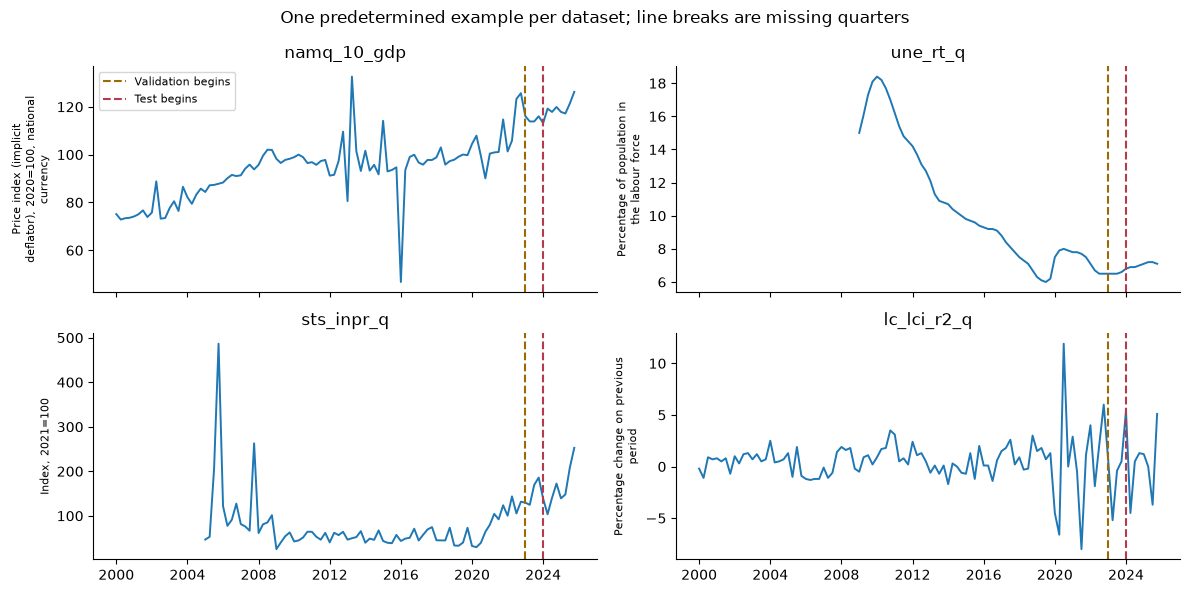

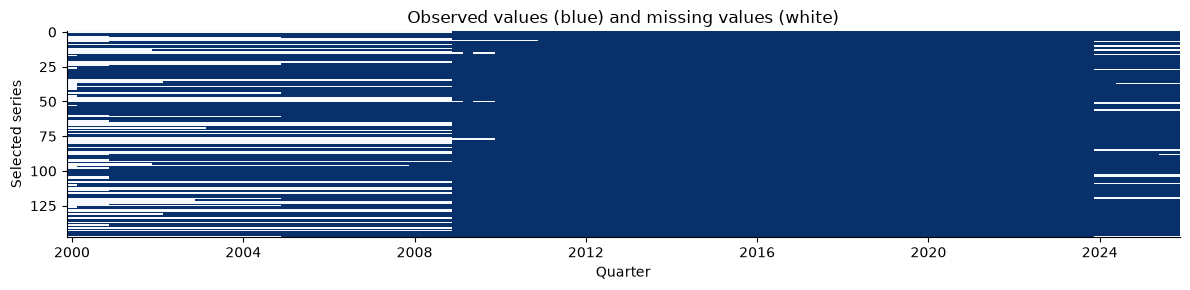

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
example_rows = [metadata["dataset_id"].to_list().index(name) for name in DATASETS if name in metadata["dataset_id"].to_list()]
for ax, i in zip(axes.flat, example_rows):
    ax.plot(DATES, panel[i], lw=1.4)
    ax.axvline(dt.date(2023, 1, 1), color="#9b6a00", ls="--", label="Validation begins")
    ax.axvline(dt.date(2024, 1, 1), color="#b43a4c", ls="--", label="Test begins")
    ax.set_title(metadata["dataset_id"][i]); ax.set_ylabel(textwrap.fill(str(metadata["units"][i]), 30), fontsize=8)
for ax in list(axes.flat)[len(example_rows):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=8)
fig.suptitle("One predetermined example per dataset; line breaks are missing quarters")
fig.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(12, 3))
ax.imshow(np.isfinite(panel), aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(0, len(DATES), 16), [str(d.year) for d in DATES[::16]])
ax.set(xlabel="Quarter", ylabel="Selected series", title="Observed values (blue) and missing values (white)")
plt.tight_layout(); plt.show()

## 3. Fix the forecasting protocol before fitting

| Role | Target dates | How used |
|---|---|---|
| Train | Through 2022Q4 | 24-quarter contexts, four-quarter targets, stride four |
| Validation | 2023Q1–Q4 | Choose the epoch with lowest normalized validation MAE |
| Test origin 1 | 2024Q1–Q4 | Forecast using history through 2023Q4 |
| Test origin 2 | 2025Q1–Q4 | Forecast using history through 2024Q4 |

All series share the same cutoffs. No training target reaches validation or test dates. At the
second test origin, 2024 observations may enter the context because they are now historical.
The network weights remain frozen; ETS is fitted separately at each origin. Both use the same
24-quarter history. We do not refit the network after validation.

This is a **latest-vintage retrospective evaluation**: revisions and publication lags are not
reconstructed. Metadata, aggregates and related datasets can overlap, so this does not establish
transfer to unseen indicators. See [leakage.md](../docs/leakage.md).

In [4]:
train = make_windows(panel, range(CONTEXT, TRAIN_STOP - HORIZON + 1, HORIZON), CONTEXT, HORIZON)
valid = make_windows(panel, [VALID_ORIGIN], CONTEXT, HORIZON)
assert (train["origin"] + HORIZON <= TRAIN_STOP).all()
assert TRAIN_STOP == VALID_ORIGIN and VALID_ORIGIN + HORIZON <= min(TEST_ORIGINS)
if len(train["X"]) == 0 or len(valid["X"]) == 0:
    raise RuntimeError("No usable train/validation windows. Inspect coverage; do not change cutoffs based on test scores.")
display(pd.DataFrame([
    {"split": name, "windows": len(w["X"]), "observed_target_values": int(w["y_mask"].sum()),
     "missing_context_fraction": float(1 - w["X_mask"].mean())}
    for name, w in [("train", train), ("validation", valid)]
]))

,split,windows,observed_target_values,missing_context_fraction
0,train,2132,8528,0.005687
1,validation,148,592,0.000000


## 4. A small residual MLP with an observation mask

Each context is centered and scaled using its **own observed history only**. Missing standardized
inputs receive zero, and the observation mask is appended, so the network can distinguish them
from actual values equal to the mean. Targets are never imputed: a masked loss averages observed
target errors per window, then averages windows.

The model projects 48 inputs (24 numbers + 24 mask bits) to width 64, applies two residual blocks,
and predicts four quarters directly. A seasonal skip connection starts near seasonal naive;
the learned head adds a correction. This is a compact ResNet-style MLP, not an image ResNet.

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(width, width), nn.ReLU(), nn.Linear(width, width))
    def forward(self, x):
        return x + self.layers(x)

class QuarterlyResNet(nn.Module):
    def __init__(self, context=24, horizon=4, width=64):
        super().__init__()
        self.context, self.horizon = context, horizon
        self.body = nn.Sequential(nn.Linear(2*context, width), nn.ReLU(),
                                  ResidualBlock(width), nn.ReLU(), ResidualBlock(width), nn.ReLU())
        self.head = nn.Linear(width, horizon)
        nn.init.zeros_(self.head.weight); nn.init.zeros_(self.head.bias)
    def forward(self, features):
        seasonal = features[:, self.context-4:self.context].repeat(1, (self.horizon+3)//4)[:, :self.horizon]
        return seasonal + self.head(self.body(features))

def tensors(w):
    features, mean, scale = normalize_context(w["X"])
    targets = np.where(w["y_mask"], (w["y"]-mean)/scale, 0.).astype("float32")
    return (torch.from_numpy(features), torch.from_numpy(targets),
            torch.from_numpy(w["y_mask"].astype("float32")))

def masked_mae(pred, target, mask):
    return (((pred-target).abs()*mask).sum(1) / mask.sum(1).clamp_min(1)).mean()

model = QuarterlyResNet(CONTEXT, HORIZON).cpu()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
tx, ty, tm = tensors(train)
vx, vy, vm = tensors(valid)
print("Parameters:", sum(p.numel() for p in model.parameters()), "| device:", next(model.parameters()).device)

Parameters: 20036 | device: cpu


Epoch  1: train=0.9208, validation=0.7956
Epoch  5: train=0.8585, validation=0.7410


Epoch 10: train=0.7902, validation=0.7209
Epoch 15: train=0.7556, validation=0.7023


Epoch 20: train=0.7384, validation=0.7055
Epoch 25: train=0.7287, validation=0.7118
Selected epoch 21 using validation only; CPU training: 0.8s


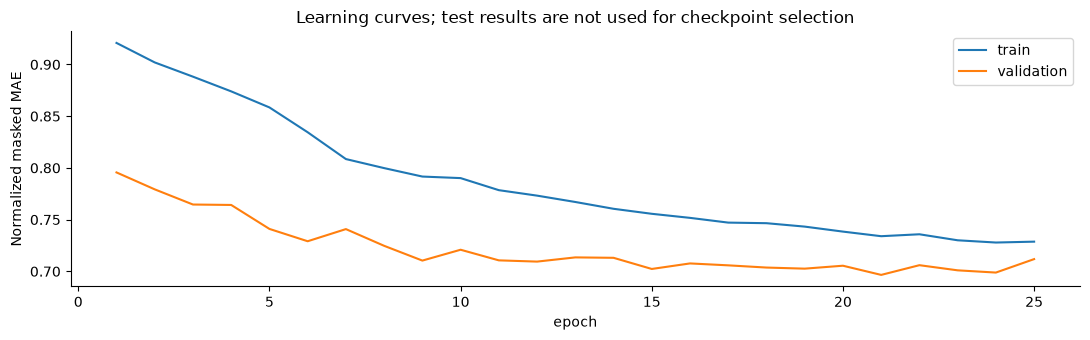

In [6]:
history, best_loss, best_state, best_epoch = [], float("inf"), None, None
generator = torch.Generator().manual_seed(SEED)
started = time.perf_counter()
for epoch in range(1, EPOCHS+1):
    model.train()
    total = 0.
    for batch in torch.randperm(len(tx), generator=generator).split(256):
        optimizer.zero_grad()
        loss = masked_mae(model(tx[batch]), ty[batch], tm[batch])
        if not torch.isfinite(loss):
            raise RuntimeError("Nonfinite training loss; inspect contexts and scaling.")
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.)
        optimizer.step()
        total += loss.item()*len(batch)
    model.eval()
    with torch.no_grad():
        validation_loss = masked_mae(model(vx), vy, vm).item()
    history.append({"epoch": epoch, "train": total/len(tx), "validation": validation_loss})
    if validation_loss < best_loss:
        best_loss, best_state, best_epoch = validation_loss, copy.deepcopy(model.state_dict()), epoch
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:2}: train={total/len(tx):.4f}, validation={validation_loss:.4f}")
if best_state is None:
    raise RuntimeError("No finite validation checkpoint.")
model.load_state_dict(best_state)
train_seconds = time.perf_counter()-started
print(f"Selected epoch {best_epoch} using validation only; CPU training: {train_seconds:.1f}s")
pd.DataFrame(history).set_index("epoch").plot(y=["train", "validation"], ylabel="Normalized masked MAE",
    title="Learning curves; test results are not used for checkpoint selection")
plt.tight_layout(); plt.show()

## 5. Compare with local exponential smoothing and seasonal naive

Use the **same test windows and target mask** for all models. For ETS and seasonal naive only,
forward-fill missing context values from earlier observations; trim leading missing context.
This is an explicit, causal transformation of a model-input copy. The stored data, plotted data,
and evaluation targets retain their missing values. No interpolation from future targets is allowed.

ETS uses additive trend, a damped trend, additive seasonality with period four, and no Box-Cox
transform. It is a fixed specification; no test-driven order search. Each fit uses standardized
context values for numerical stability, then predictions return to original units. Failed or
nonconverged fits use seasonal naive and are counted as fallbacks. The table labels this combined
method honestly; a separate table reports successful ETS fits on common support.

MASE uses observed seasonal pairs in the original 24-quarter context. A constant context has
undefined MASE and stays in the MAE/sMAPE results. Report both mean and median MASE and the number
of valid cases. MASE=1 refers to an in-sample scale; beating the test seasonal-naive score must
be checked directly. sMAPE uses 0 for a pair of zeros. Aggregate metrics weight series equally
after averaging their available test origins. Missing targets are never scored.

In [7]:
test = make_windows(panel, TEST_ORIGINS, CONTEXT, HORIZON)
if len(test["X"]) == 0:
    raise RuntimeError("No scoreable test windows; report coverage instead of inventing a result.")
features, mean, scale = normalize_context(test["X"])
model.eval()
started = time.perf_counter()
with torch.no_grad():
    neural = model(torch.from_numpy(features)).numpy()*scale + mean
neural_seconds = time.perf_counter()-started
naive, ets, ets_status, ets_warnings = [], [], [], []
started = time.perf_counter()
for x, mu, sigma in zip(test["X"], mean[:, 0], scale[:, 0]):
    filled = pd.Series(x).ffill().dropna().to_numpy()  # only the leading missing prefix is trimmed
    baseline = np.resize(filled[-4:], HORIZON)
    naive.append(baseline)
    try:
        if len(filled) < 8:
            raise ValueError("fewer than two complete seasonal cycles after leading trim")
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            fit = ExponentialSmoothing((filled-mu)/sigma, trend="add", damped_trend=True,
                seasonal="add", seasonal_periods=4, initialization_method="estimated").fit(optimized=True)
            pred = np.asarray(fit.forecast(HORIZON))*sigma + mu
        ets_warnings.append(" | ".join(str(w.message) for w in caught))
        if not fit.mle_retvals.get("success", True) or not np.isfinite(pred).all():
            raise ValueError("optimizer did not converge or forecast was not finite")
        ets.append(pred); ets_status.append("ok")
    except (ValueError, RuntimeError, FloatingPointError, np.linalg.LinAlgError) as exc:
        ets.append(baseline); ets_status.append(f"fallback: {exc}")
        if len(ets_warnings) < len(ets_status):
            ets_warnings.append("")
ets_seconds = time.perf_counter()-started
predictions = {"Seasonal naive": np.asarray(naive), "ETS + naive fallback": np.asarray(ets), "Shared ResNet": neural}
records = []
for name, pred in predictions.items():
    scores = score_forecasts(test["y"], pred, test["X"])
    for k, row in enumerate(test["row"]):
        records.append(dict(model=name, series_uid=metadata["series_uid"][int(row)],
            dataset_id=metadata["dataset_id"][int(row)], origin=str(DATES[test["origin"][k]]),
            mae=scores["mae"][k], mase=scores["mase"][k], smape=scores["smape"][k],
            observed_targets=int(scores["observed_targets"][k]), ets_status=ets_status[k],
            ets_warning=ets_warnings[k]))
results = pd.DataFrame(records)
per_series = results.groupby(["model", "series_uid"])[["mae", "mase", "smape"]].mean().reset_index()
summary = per_series.groupby("model").agg(series=("series_uid", "size"), valid_mase_series=("mase", "count"),
    mean_mase=("mase", "mean"), median_mase=("mase", "median"), mean_smape=("smape", "mean"))
display(summary.round(3))
print(f"Network inference: {neural_seconds:.3f}s; ETS fits: {ets_seconds:.1f}s")
print("ETS successful:", ets_status.count("ok"), "/", len(ets_status), "| fits with warnings:", sum(bool(w) for w in ets_warnings))
coverage = pd.DataFrame([dict(origin=str(DATES[o]), selected_series=len(panel),
    evaluated_series=int((test["origin"] == o).sum()),
    observed_targets=int(test["y_mask"][test["origin"] == o].sum()),
    possible_targets=len(panel)*HORIZON) for o in TEST_ORIGINS])
display(coverage)
display(results[results.ets_status == "ok"].groupby("model").agg(
    successful_fit_windows=("series_uid", "size"), mean_mase=("mase", "mean"), median_mase=("mase", "median")))

,series,valid_mase_series,mean_mase,median_mase,mean_smape
model,,,,,
ETS + naive fallback,134,133,0.626,0.517,31.966
Seasonal naive,134,133,0.788,0.679,33.620
Shared ResNet,134,133,0.633,0.515,34.671


Network inference: 0.001s; ETS fits: 21.4s
ETS successful: 265 / 267 | fits with warnings: 2


,origin,selected_series,evaluated_series,observed_targets,possible_targets
0,2024-01-01,148,134,534,592
1,2025-01-01,148,133,530,592


,successful_fit_windows,mean_mase,median_mase
model,,,
ETS + naive fallback,265,0.627722,0.473862
Seasonal naive,265,0.789572,0.653742
Shared ResNet,265,0.634531,0.507905


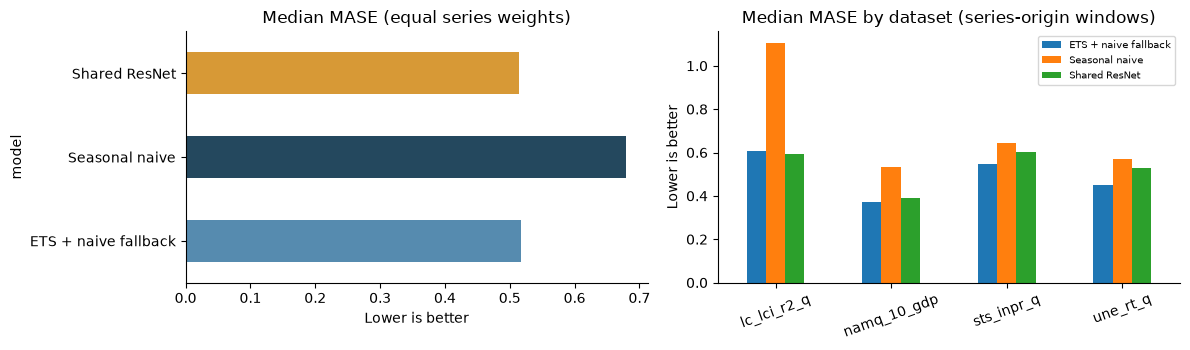

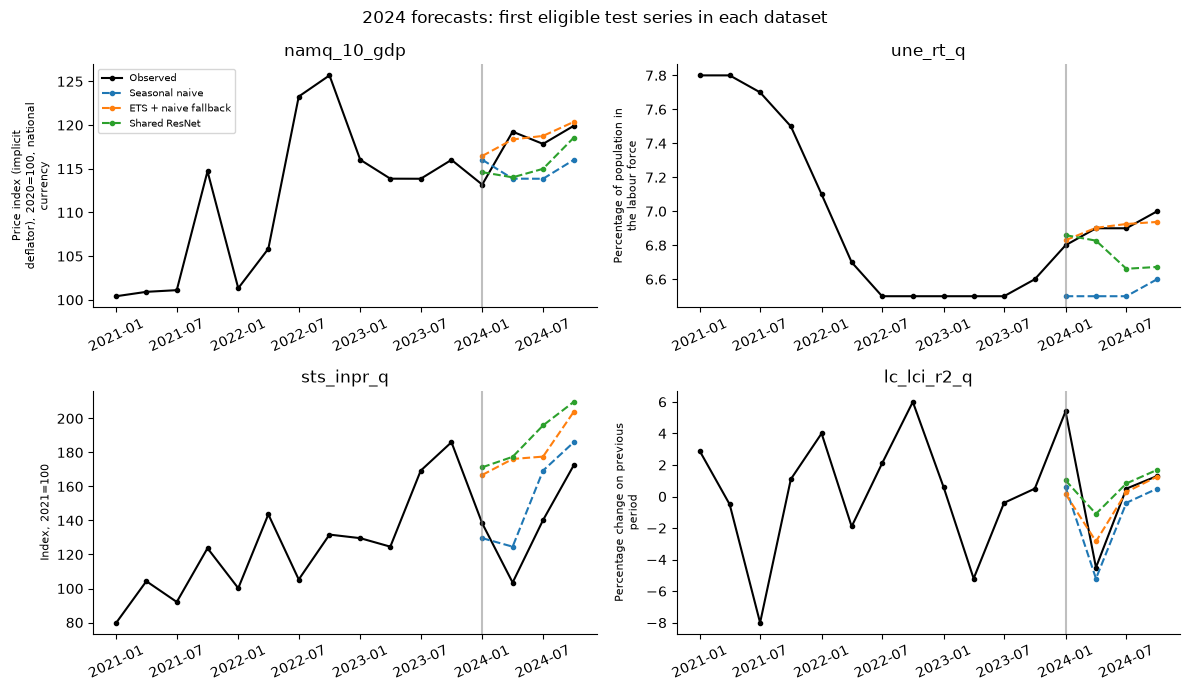

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
summary["median_mase"].plot.barh(ax=axes[0], color=["#568baf", "#24485e", "#d79936"])
axes[0].set(title="Median MASE (equal series weights)", xlabel="Lower is better")
results.groupby(["dataset_id", "model"])["mase"].median().unstack().plot.bar(ax=axes[1])
axes[1].set(title="Median MASE by dataset (series-origin windows)", ylabel="Lower is better", xlabel="")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, dataset in zip(axes.flat, DATASETS):
    candidates_k = [k for k, r in enumerate(test["row"]) if metadata["dataset_id"][int(r)] == dataset
                    and test["origin"][k] == TEST_ORIGINS[0]]
    if not candidates_k:
        ax.set_visible(False); continue
    k = candidates_k[0]  # fixed order, never choose examples by error
    row, origin = int(test["row"][k]), int(test["origin"][k])
    ax.plot(DATES[origin-12:origin+HORIZON], panel[row, origin-12:origin+HORIZON], "o-", color="black", ms=3, label="Observed")
    for name, pred in predictions.items():
        ax.plot(DATES[origin:origin+HORIZON], pred[k], "o--", ms=3, label=name)
    ax.axvline(DATES[origin], color="grey", alpha=.5)
    ax.set_title(dataset); ax.set_ylabel(textwrap.fill(str(metadata["units"][row]), 30), fontsize=8)
    ax.tick_params(axis="x", rotation=25)
axes.flat[0].legend(fontsize=7)
fig.suptitle("2024 forecasts: first eligible test series in each dataset")
plt.tight_layout(); plt.show()

## 6. Save the evidence and interpret the result

A small shared model may lose to ETS. That is useful evidence, not a failed tutorial. Compare
datasets and coverage before making an aggregate claim. These series are dependent (units,
geographic aggregates and related indicators), so ordinary independent-series confidence intervals
would overstate certainty. A research benchmark should add multiple seeds and blocked uncertainty
estimates, broader rolling origins, data-family holdouts, and vintage-aware observations.

The next cell creates a new run directory with settings, selected series, source file checksums,
exact library versions, model weights, learning curves, predictions and scores. Data and predictions
remain local under ignored `reports/`; the notebook's displayed examples are for inspection.
Seeded runs on the same environment should be repeatable; versions and platforms can change results.

References: [time-series cross-validation](https://otexts.com/fpp3/tscv.html),
[forecast accuracy and MASE](https://otexts.com/fpp3/accuracy.html),
[statsmodels exponential smoothing](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html),
[PyTorch reproducibility](https://docs.pytorch.org/docs/stable/notes/randomness.html).

In [9]:
run_id = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
output = ROOT / "reports" / "quarterly_forecasting" / run_id
output.mkdir(parents=True, exist_ok=False)

def sha256(path):
    with open(path, "rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()

versions = {name: importlib.metadata.version(name) for name in
            ["terrastat", "numpy", "pandas", "polars", "torch", "statsmodels", "matplotlib"]}
git = subprocess.run(["git", "rev-parse", "HEAD"], cwd=ROOT, capture_output=True, text=True)
manifest = dict(run_id=run_id, synthetic_smoke=SMOKE, input_mode=INPUT_MODE,
    snapshot=str(snapshot_root) if snapshot_root is not None else None,
    seed=SEED, context=CONTEXT, horizon=HORIZON,
    epochs=EPOCHS, selected_epoch=best_epoch, train_end=str(TRAIN_END), validation_origin=str(DATES[VALID_ORIGIN]),
    test_origins=[str(DATES[o]) for o in TEST_ORIGINS], per_dataset=PER_DATASET,
    candidates_per_dataset=CANDIDATES_PER_DATASET, datasets=DATASETS, geos=GEOS,
    versions=versions, python=platform.python_version(), platform=platform.platform(),
    git_commit=git.stdout.strip() if git.returncode == 0 else None,
    train_seconds=train_seconds, neural_inference_seconds=neural_seconds, ets_seconds=ets_seconds,
    ets_fallbacks=sum(s != "ok" for s in ets_status), audit=audit,
    source_files=[] if SMOKE else [{"path": str(p), "sha256": sha256(p)} for p in files],
    code_files=[{"path": str(p.relative_to(ROOT)), "sha256": sha256(p)} for p in
        [ROOT / "notebooks/_build_quarterly_forecasting.py", ROOT / "src/terrastat/forecasting.py",
         ROOT / "src/terrastat/calendar.py"]],
    interpretation="Retrospective latest-vintage pooled forecasting; not real-time or zero-shot.")
(output / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
metadata.write_parquet(output / "cohort.parquet")
np.savez_compressed(output / "predictions.npz", panel=panel, dates=np.array([str(d) for d in DATES]),
    test_row=test["row"], test_origin=test["origin"], targets=test["y"], target_mask=test["y_mask"],
    neural=neural, ets=np.asarray(ets), seasonal_naive=np.asarray(naive))
results.to_csv(output / "scores.csv", index=False)
summary.to_csv(output / "summary.csv")
coverage.to_csv(output / "coverage.csv", index=False)
pd.DataFrame(history).to_csv(output / "learning_curve.csv", index=False)
torch.save(model.state_dict(), output / "model.pt")
print("Saved:", display_path(output))

Saved: .\reports\quarterly_forecasting\20260917T125619521163Z
